### Autor: David Roca Tauste

---
# PASO 1: IMPLEMENTA EN PYTHON EL PERCEPTRÓN.

In [1]:
# coding: utf-8
import numpy as np
import os
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

class Perceptron(object):
    def __init__(self, eta=0.01, n_iter=50, semilla=1):
        self.eta = eta
        self.n_iter = n_iter
        self.semilla = semilla

    def fit(self, X, y):
        rgen = np.random.RandomState(self.semilla)
        self.w_ = rgen.normal(loc=0.0, scale=0.01, size=1 + X.shape[1])
        self.errores_ = []
        for _ in range(self.n_iter):
            errores = 0
            for xi, target in zip(X, y):
                incremento = self.eta * (target - self.predict(xi))
                self.w_[1:] += incremento * xi
                self.w_[0] += incremento
                errores += int(incremento != 0.0)
            self.errores_.append(errores)
        return self

    def net_input(self, X):
        return np.dot(X, self.w_[1:]) + self.w_[0]

    def predict(self, X):
        return np.where(self.net_input(X) >= 0.0, 1, -1)

v1 = np.array([1, 2, 3])
v2 = 0.5 * v1
np.arccos(v1.dot(v2) / (np.linalg.norm(v1) * np.linalg.norm(v2)))

np.float64(0.0)

## PREGUNTA 1
### ¿Porqué no inicializar los pesos de la neurona directamente todos a 0?
 - Porque el learning rate también se queda a 0.
 - `Porque el vector de pesos w representa una línea recta y si inicialmente es 0, cuando falla al predecir y actualiza, al multiplicarlo, cambia su tamaño pero nunca su dirección.`


---
# PASO 2: PREPARAR EL DATASET IRIS.

In [ ]:
# ## PASO 2: PREPARAR EL DATASET

# Leer el dataset: <lugar> puede ser una ruta o una URL
# pd.read('https://archive.ics.uci.edu/ml/machine-learning-databases/iris/iris.data', header=None)
# pd.read('c:\usuarios\manolo\datasets\iris.data', header=None)

lugar = "iris.data"
print("---- Leyendo dataset de:", lugar)
df = pd.read_csv(lugar, header=None, encoding="utf-8")
print("---- Últimos 5 ejemplos:\n", df.tail())

---- Leyendo dataset de: iris.data
---- Últimos 5 ejemplos:
        0    1    2    3               4
145  6.7  3.0  5.2  2.3  Iris-virginica
146  6.3  2.5  5.0  1.9  Iris-virginica
147  6.5  3.0  5.2  2.0  Iris-virginica
148  6.2  3.4  5.4  2.3  Iris-virginica
149  5.9  3.0  5.1  1.8  Iris-virginica


## PREGUNTA 2
### ¿Para qué sirve el parámetro header del método read_csv()?
El parámetro "header=None" se está utilizando porque iris.data no tiene un encabezado en la primera fila. Sirve para que pandas asigne índices  como nombres de las columnas del DataFrame.

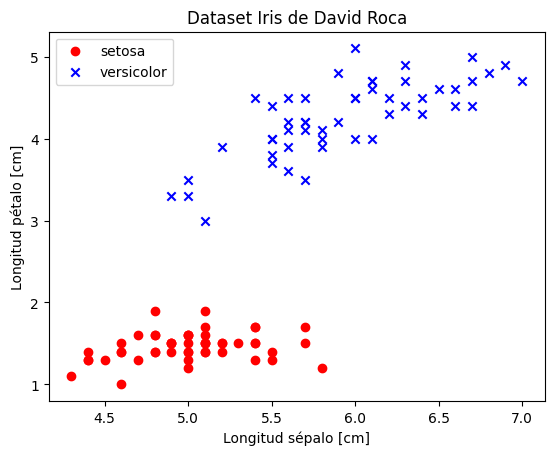

In [3]:
y = df.iloc[0:100, 4].values  # seleccionar ejemplos de setosa y versicolor
y = np.where(y == 'Iris-setosa', -1, 1)  # Codificarlos en +1 (Iris-Versicolor) y -1 (Iris-setosa)
X = df.iloc[0:100, [0, 2]].values  # extraer longitud de sépalos y pétalos

# Dibujar los datos
plt.scatter(X[:50, 0], X[:50, 1], color='red', marker='o', label='setosa')
plt.scatter(X[50:100, 0], X[50:100, 1], color='blue', marker='x', label='versicolor')
plt.xlabel('Longitud sépalo [cm]')
plt.ylabel('Longitud pétalo [cm]')
plt.legend(loc='upper left')
plt.title(loc='center', label='Dataset Iris de David Roca')
plt.show()  # plt.savefig('images/02_06.png', dpi=300)

## PREGUNTA 3
### Pon tu nombre y primer apellido al título del gráfico tal y como te propone el código y entrega una captura del gráfico con el nombre u02_p01_03.png.
Se encuentra arriba.

## PREGUNTA 4
### Viendo como están distribuidas las flores del dataset y teniendo en cuenta que el perceptrón es un clasificador lineal, ¿debería ser capaz de encontrar una línea que separe perfectamente los dos tipos o clases de flores? Traza una línea que separe ambas clases usando un programa de edición de imágenes y la entregas como u02_p01_04.png. ¿Puedes decirme qué linea es? Darme aproximadamente su ecuación.
El perceptrón sí debería ser capaz de encontrar una línea que separe perfectamente los dos tipos o clases de flores porque hay un espacio considerable entre estos dos tipos de flores.
La línea que he dibujado se llama línea separadora y la ecuación de la línea sería esta: w1 x1 + w2 x2 + b = 0.

---
# PASO 3: CREAR Y ENTRENAR UN PERCEPTÓN.

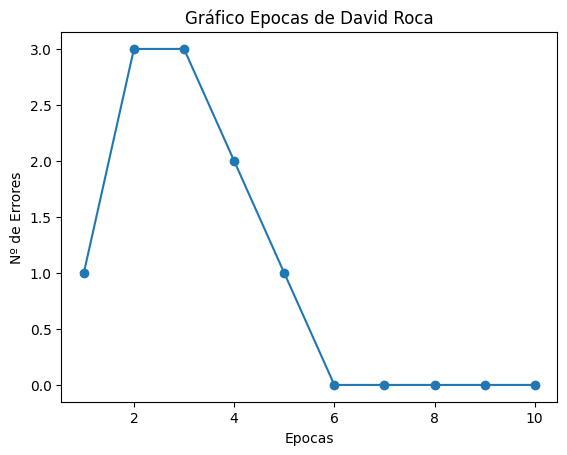

In [22]:
ppn = Perceptron(eta=0.1, n_iter=10)
ppn.fit(X, y)
plt.plot(range(1, len(ppn.errores_) + 1), ppn.errores_, marker="o")
plt.xlabel("Epocas")
plt.ylabel("Nº de Errores")
plt.title(loc="center", label="Gráfico Epocas de David Roca")
plt.show()  # plt.savefig('images/U02_P01_02.png', dpi=300)

## PREGUNTA 5
### Pon tu nombre y primer apellido al título del gráfico tal y como te propone el código y entrega una captura del gráfico con el nombre U02_P01_05.png.
Se encuentra arriba.

## PREGUNTA 6
### ¿Sería cierto decir que durante el entrenamiento en la época 2 y 3 es cuando comete más errores el modelo?
 - `Sí.` (Justo en este caso sí. De manera general sería que no porque lo normal es que la época 1 y 2 sean las que cometen más errores.)
 - No.

### Marca la época en que comienza a converger el modelo?
 - 2
 - `4`
 - 6
 - 8

### Si bajas el learning rate a 0.01 (el parámetro eta) ¿El modelo converge?
 - Antes.
 - `Más lentamente.`
 - No converge salvo que aumentes las iteraciones.

### Marca la afirmación correcta sobre este gráfico que acabamos de generar:
 - Muestra como es la frontera de decisión de los datos cuando la aprende.
 - `Sirve vigilar durante el entrenamiento, la cantidad de errores que va cometiendo.`

### Al acabar de entrenar la cantidad de errores que comete es 0. ¿Significa que tenemos un modelo perfecto?
 - Sí. Como no comete errores, lo hemos creado con un rendimiento inmejorable.
 - `No. Necesitamos saber como se comporta con datos que no ha usado para entrenar.`

---
# PASO 4: GRAFICAR EL RESULTADO.

C:\Users\davil\AppData\Local\Temp\ipykernel_1476\3737311034.py:21: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(


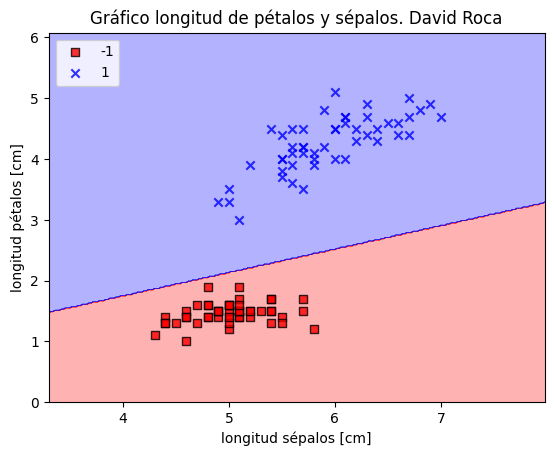

In [5]:
## PASO 4: función para dibujar regiones de decisión
def plot_regiones(X, y, clasificador, resolucion=0.02):
    marcadores = ("s", "x", "o", "^", "v")
    colores = ("red", "blue", "lightgreen", "gray", "cyan")
    cmap = ListedColormap(colores[: len(np.unique(y))])

    # Dibujar la superficie de decisión
    x1_min, x1_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    x2_min, x2_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx1, xx2 = np.meshgrid(
        np.arange(x1_min, x1_max, resolucion), np.arange(x2_min, x2_max, resolucion)
    )
    Z = clasificador.predict(np.array([xx1.ravel(), xx2.ravel()]).T)
    Z = Z.reshape(xx1.shape)
    plt.contourf(xx1, xx2, Z, alpha=0.3, cmap=cmap)
    plt.xlim(xx1.min(), xx1.max())
    plt.ylim(xx2.min(), xx2.max())

    # Dibujar la clase de los ejemplos
    for idx, cl in enumerate(np.unique(y)):
        plt.scatter(
            x=X[y == cl, 0],
            y=X[y == cl, 1],
            alpha=0.8,
            c=colores[idx],
            marker=marcadores[idx],
            label=cl,
            edgecolor="black",
        )


# Por último hacemos una llamada a la función para generar el gráfico:
plot_regiones(X, y, clasificador=ppn)
plt.xlabel("longitud sépalos [cm]")
plt.ylabel("longitud pétalos [cm]")
plt.legend(loc="upper left")  # plt.savefig('images/U02_P01_3.png', dpi=300)
plt.title(loc="center", label="Gráfico longitud de pétalos y sépalos. David Roca")
plt.show()

## PREGUNTA 7
### Pon tu nombre y primer apellido al título del gráfico y entrega una captura del gráfico con el nombre u02_p01_07.png.
Se encuentra arriba.